## Packages

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Importing Data

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train : ",x_train.shape)
print("y_train : ",y_train.shape)
print("x_test  : ",x_test.shape)
print("y_test  : ",y_test.shape)

x_train :  (60000, 28, 28)
y_train :  (60000,)
x_test  :  (10000, 28, 28)
y_test  :  (10000,)


## Data Normalization

In [3]:
xmax=x_train.max()
x_train = x_train / xmax
x_test  = x_test  / xmax

### Some examples

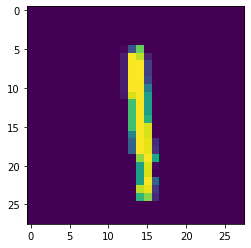

In [4]:
plt.imshow(x_train[8])

In [5]:
y_train[2]

4

## Building model


In [6]:
hidden1     = 100
hidden2     = 100

model = keras.Sequential([
    keras.layers.Input((28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense( hidden1, activation='relu'),
    keras.layers.Dense( hidden2, activation='relu'),
    keras.layers.Dense( 10,      activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Train the model

In [7]:
batch_size  = 512
epochs      =  16

history = model.fit(  x_train, y_train,
                      batch_size      = batch_size,
                      epochs          = epochs,
                      verbose         = 1,
                      validation_data = (x_test, y_test))

Epoch 1/16
118/118 [==============================] - 2s 16ms/step - loss: 1.0439 - accuracy: 0.6967 - val_loss: 0.2520 - val_accuracy: 0.9279
Epoch 2/16
118/118 [==============================] - 1s 6ms/step - loss: 0.2415 - accuracy: 0.9311 - val_loss: 0.1840 - val_accuracy: 0.9454
Epoch 3/16
118/118 [==============================] - 1s 6ms/step - loss: 0.1750 - accuracy: 0.9492 - val_loss: 0.1496 - val_accuracy: 0.9542
Epoch 4/16
118/118 [==============================] - 1s 6ms/step - loss: 0.1401 - accuracy: 0.9601 - val_loss: 0.1277 - val_accuracy: 0.9613
Epoch 5/16
118/118 [==============================] - 1s 6ms/step - loss: 0.1112 - accuracy: 0.9679 - val_loss: 0.1131 - val_accuracy: 0.9650
Epoch 6/16
118/118 [==============================] - 1s 6ms/step - loss: 0.0958 - accuracy: 0.9722 - val_loss: 0.1076 - val_accuracy: 0.9673
Epoch 7/16
118/118 [==============================] - 1s 6ms/step - loss: 0.0854 - accuracy: 0.9746 - val_loss: 0.0957 - val_accuracy: 0.9713
Epoch

## Evaluation of the model


In [8]:
score = model.evaluate(x_test, y_test, verbose=0)

print('Test loss     :', score[0])
print('Test accuracy :', score[1])

Test loss     : 0.08090905845165253
Test accuracy : 0.9761999845504761


## Plot history

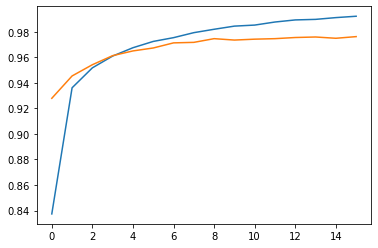

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

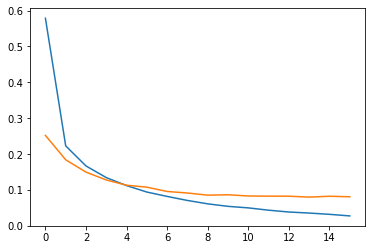

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

## Performance Analysis

In [11]:
y_softmax = model.predict(x_test)
y_pred    = np.argmax(y_softmax, axis=-1)

In [12]:
errors=[ i for i in range(len(x_test)) if y_pred[i]!=y_test[i] ]
len(errors)

238

In [13]:
print(confusion_matrix(y_test, y_pred)) # order matters! (actual, predicted)

[[ 973    0    1    0    0    1    1    1    3    0]
 [   0 1123    4    0    0    1    2    1    4    0]
 [   4    2 1013    0    1    0    3    3    5    1]
 [   1    0   12  975    0   10    1    4    5    2]
 [   0    0    4    0  967    1    2    1    1    6]
 [   2    0    1    5    1  874    6    0    2    1]
 [   6    2    1    0    6    6  934    0    3    0]
 [   1    7   14    1    2    0    0  995    2    6]
 [   6    0    5    2    4    7    1    3  941    5]
 [   3    3    3    7   14    5    0    3    4  967]]


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.98      0.97      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.98      0.97       892
           6       0.98      0.97      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

